# Handwritten Math Symbol Classification

Comparing three feature extraction methods — **raw pixels**, **HOG**, and **LBP** — across two classifiers (**SVM** and a simple **Artificial Neural Network**) for classifying handwritten mathematical symbols (`=`, `4`, `9`, `b`, `C`, `cos`, `geq`, `leq`, `M`, `rightarrow`).

## 1. Setup

In [ ]:
!pip install opencv-python-headless



zsh:1: command not found: pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from skimage import feature
from sklearn import svm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import tensorflow as tf
from tensorflow import keras

%matplotlib inline
print("TensorFlow version:", tf.__version__)

Matplotlib is building the font cache; this may take a moment.


TensorFlow version: 2.21.0


## 2. Data Loading

Loads grayscale images from class-labelled subfolders and resizes them to 28x28.

In [5]:
def load_dataset(dataset_path, classes, image_size=(28, 28)):
    """Loads grayscale images from per-class subfolders into arrays."""
    images = []
    labels = []

    for label in classes:
        label_path = os.path.join(dataset_path, label)


        for filename in os.listdir(label_path):
            image_path = os.path.join(label_path, filename)
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                print("Could not read:", image_path)
                continue

            img = cv2.resize(img, image_size)
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

In [6]:
DATASET_PATH = "Dataset"
CLASSES = ['=', '4', '9', 'b', 'C', 'cos', 'geq', 'leq', 'M', 'rightarrow']

# Single load — the dataset is split into train/test AFTER loading, not by loading twice
X, y = load_dataset(DATASET_PATH, CLASSES)

print("Loaded images shape:", X.shape)
print("Loaded labels shape:", y.shape)

Loaded images shape: (5000, 28, 28)
Loaded labels shape: (5000,)


In [7]:
# Encode string labels into integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Single stratified train/test split, reused across all feature extraction methods
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 4000
Test size: 1000


## 3. Feature Extraction

Three representations of the same images are generated: Local Binary Patterns (LBP), Histogram of Oriented Gradients (HOG), and raw flattened pixels.

In [8]:
class LocalBinaryPattern:
    """Computes a normalised LBP histogram for a single grayscale image."""

    def __init__(self, points, radius):
        self.points = points
        self.radius = radius

    def describe(self, image, eps=1e-7):
        lbp = feature.local_binary_pattern(
            image, self.points, self.radius, method="uniform"
        )
        (hist, _) = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, self.points + 3),
            range=(0, self.points + 2)
        )
        hist = hist.astype("float")
        hist /= (hist.sum() + eps)
        return hist

In [9]:
def extract_lbp_features(images, points=34, radius=8):
    desc = LocalBinaryPattern(points, radius)
    return np.array([desc.describe(img) for img in images])


def extract_hog_features(images, orientations=7, pixels_per_cell=(7, 7), cells_per_block=(2, 2)):
    features_list = []
    for img in images:
        H = feature.hog(
            img,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            transform_sqrt=True,
            block_norm="L2-Hys"
        )
        features_list.append(H)
    return np.array(features_list)

In [10]:
# LBP features
X_train_lbp = extract_lbp_features(X_train)
X_test_lbp = extract_lbp_features(X_test)

# HOG features
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)

# Raw flattened pixels
X_train_raw = X_train.reshape((X_train.shape[0], -1))
X_test_raw = X_test.reshape((X_test.shape[0], -1))

print("LBP feature shape:", X_train_lbp.shape)
print("HOG feature shape:", X_train_hog.shape)
print("Raw pixel feature shape:", X_train_raw.shape)

LBP feature shape: (4000, 36)
HOG feature shape: (4000, 252)
Raw pixel feature shape: (4000, 784)


## 4. SVM Classification

An RBF-kernel SVM is trained and evaluated separately on each feature representation.

In [11]:
results = []  # collects (feature_type, model_type, train_acc, test_acc) for the final comparison

In [12]:
# --- SVM on LBP features ---
svm_lbp = svm.SVC(kernel='rbf', C=100.0, random_state=42)
svm_lbp.fit(X_train_lbp, y_train)

train_acc = svm_lbp.score(X_train_lbp, y_train)
test_acc = svm_lbp.score(X_test_lbp, y_test)

print(f"SVM + LBP — Train Accuracy: {train_acc:.2f} | Test Accuracy: {test_acc:.2f}")
results.append(("LBP", "SVM", train_acc, test_acc))

SVM + LBP — Train Accuracy: 0.71 | Test Accuracy: 0.67


SVM + HOG — Train Accuracy: 1.00 | Test Accuracy: 0.98


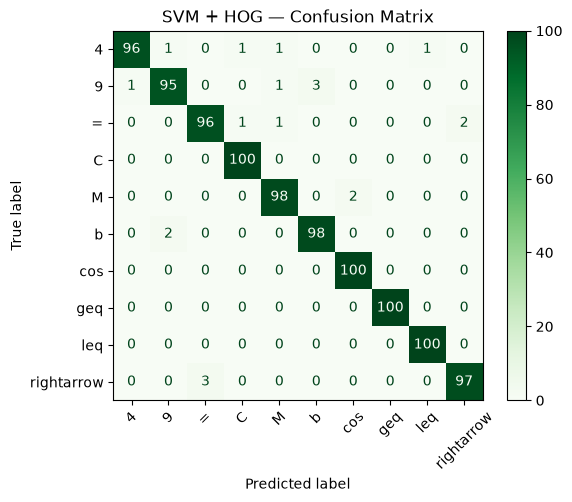

In [13]:
# --- SVM on HOG features ---
svm_hog = svm.SVC(kernel='rbf', C=100.0, random_state=42)
svm_hog.fit(X_train_hog, y_train)

train_acc = svm_hog.score(X_train_hog, y_train)
test_acc = svm_hog.score(X_test_hog, y_test)

print(f"SVM + HOG — Train Accuracy: {train_acc:.2f} | Test Accuracy: {test_acc:.2f}")
results.append(("HOG", "SVM", train_acc, test_acc))

# Confusion matrix for the SVM + HOG combination
y_pred_hog = svm_hog.predict(X_test_hog)
cm = confusion_matrix(y_test, y_pred_hog)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title("SVM + HOG — Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

In [14]:
# --- SVM on raw pixels ---
svm_raw = svm.SVC(kernel='rbf', C=100.0, random_state=42)
svm_raw.fit(X_train_raw, y_train)

train_acc = svm_raw.score(X_train_raw, y_train)
test_acc = svm_raw.score(X_test_raw, y_test)

print(f"SVM + Raw Pixels — Train Accuracy: {train_acc:.2f} | Test Accuracy: {test_acc:.2f}")
results.append(("Raw Pixels", "SVM", train_acc, test_acc))

SVM + Raw Pixels — Train Accuracy: 1.00 | Test Accuracy: 0.97


## 5. Neural Network Classification

A simple fully-connected neural network (one hidden layer, 512 units) is trained on each feature representation for comparison against the SVM results.

In [19]:
def build_and_train_ann(X_train, y_train, X_test, y_test, input_dim, num_classes, epochs=100):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=[input_dim]),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.optimizers.Adam(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=0)
    train_acc = history.history['accuracy'][-1]
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.title(f"Training history ({input_dim} input features)")
    plt.show()

    return train_acc, test_acc


NUM_CLASSES = len(CLASSES)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


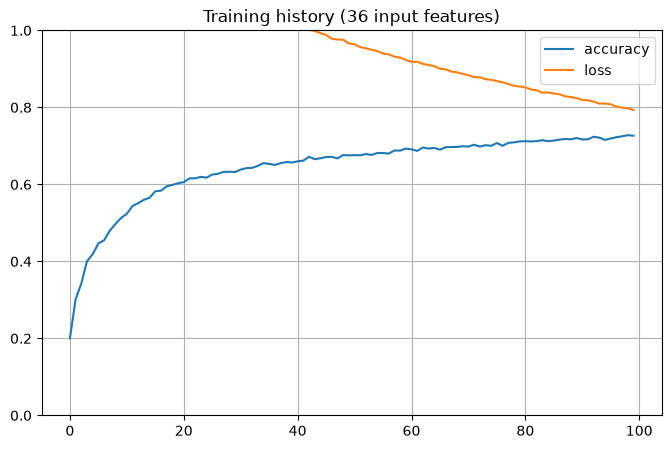

ANN + LBP — Train Accuracy: 0.73 | Test Accuracy: 0.69


In [20]:
# --- ANN on LBP features ---
train_acc, test_acc = build_and_train_ann(
    X_train_lbp, y_train, X_test_lbp, y_test,
    input_dim=X_train_lbp.shape[1], num_classes=NUM_CLASSES, epochs=100
)
print(f"ANN + LBP — Train Accuracy: {train_acc:.2f} | Test Accuracy: {test_acc:.2f}")
results.append(("LBP", "ANN", train_acc, test_acc))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


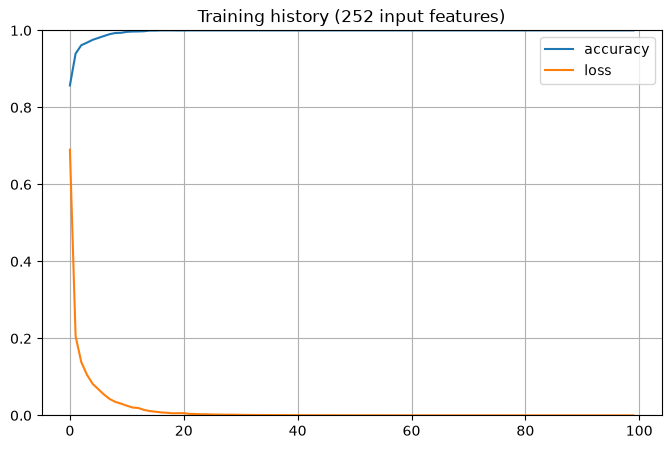

ANN + HOG — Train Accuracy: 1.00 | Test Accuracy: 0.98


In [21]:
# --- ANN on HOG features ---
train_acc, test_acc = build_and_train_ann(
    X_train_hog, y_train, X_test_hog, y_test,
    input_dim=X_train_hog.shape[1], num_classes=NUM_CLASSES, epochs=100
)
print(f"ANN + HOG — Train Accuracy: {train_acc:.2f} | Test Accuracy: {test_acc:.2f}")
results.append(("HOG", "ANN", train_acc, test_acc))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


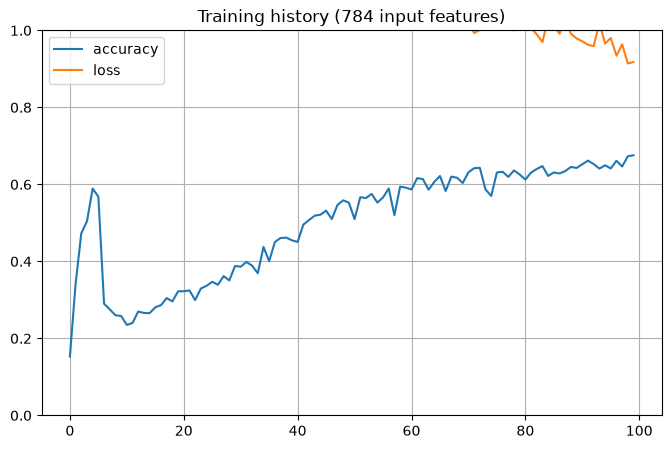

ANN + Raw Pixels — Train Accuracy: 0.68 | Test Accuracy: 0.66


In [22]:
# --- ANN on raw pixels ---
train_acc, test_acc = build_and_train_ann(
    X_train_raw, y_train, X_test_raw, y_test,
    input_dim=X_train_raw.shape[1], num_classes=NUM_CLASSES, epochs=100
)
print(f"ANN + Raw Pixels — Train Accuracy: {train_acc:.2f} | Test Accuracy: {test_acc:.2f}")
results.append(("Raw Pixels", "ANN", train_acc, test_acc))

## 6. Results Comparison

All six feature/model combinations are summarised below to compare which feature extraction method and classifier performs best.

In [23]:
results_df = pd.DataFrame(results, columns=["Feature Type", "Model", "Train Accuracy", "Test Accuracy"])
results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
results_df

,Feature Type,Model,Train Accuracy,Test Accuracy
0,HOG,SVM,1.00000,0.980
1,HOG,ANN,1.00000,0.977
2,HOG,ANN,1.00000,0.977
3,Raw Pixels,SVM,1.00000,0.973
4,LBP,ANN,0.72650,0.695
5,LBP,SVM,0.71300,0.674
6,Raw Pixels,ANN,0.67575,0.662
7,LBP,ANN,0.63275,0.621
8,Raw Pixels,ANN,0.40525,0.163
